<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------            

/tmp/ipykernel_1217/1675972229.py:24: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[' Date'] = pd.to_datetime(df[' Date'])


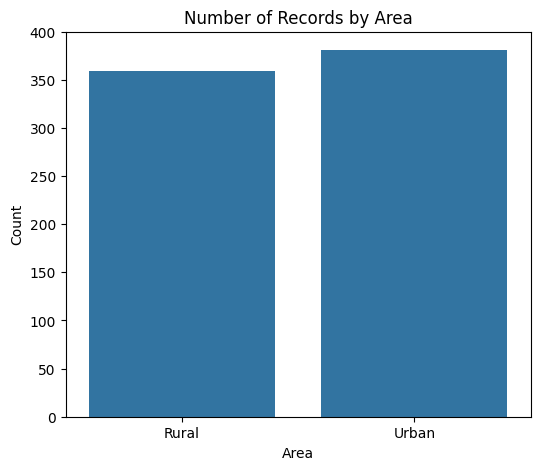

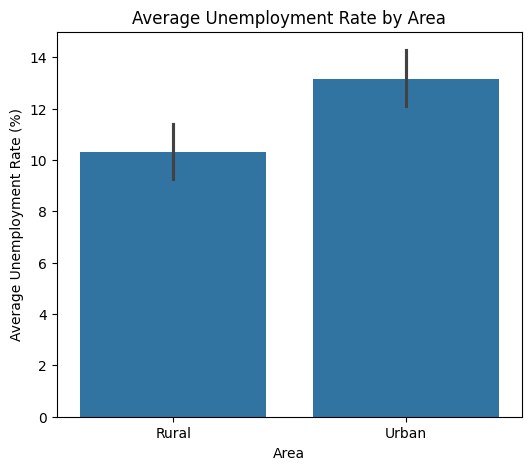

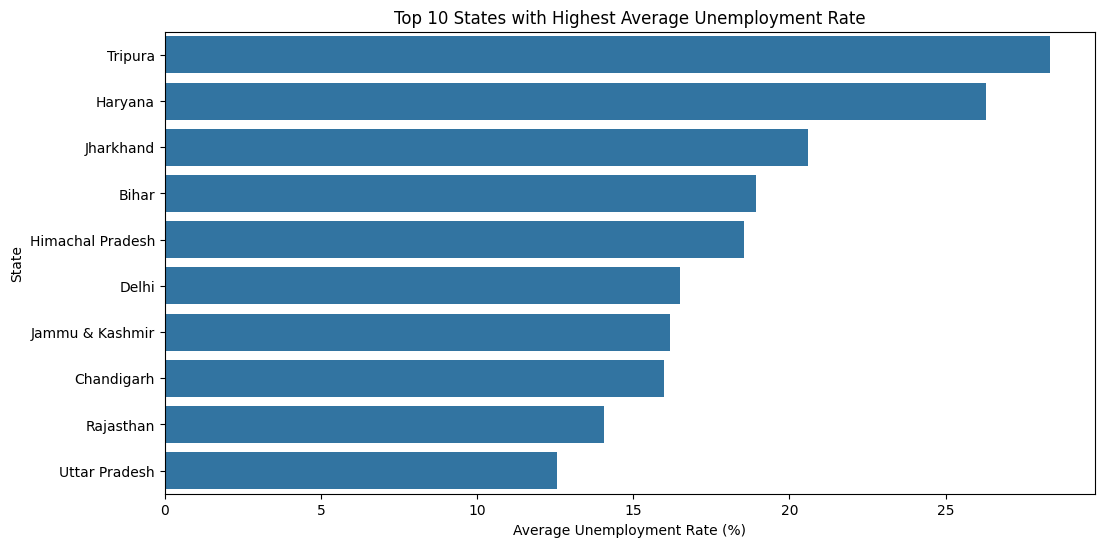

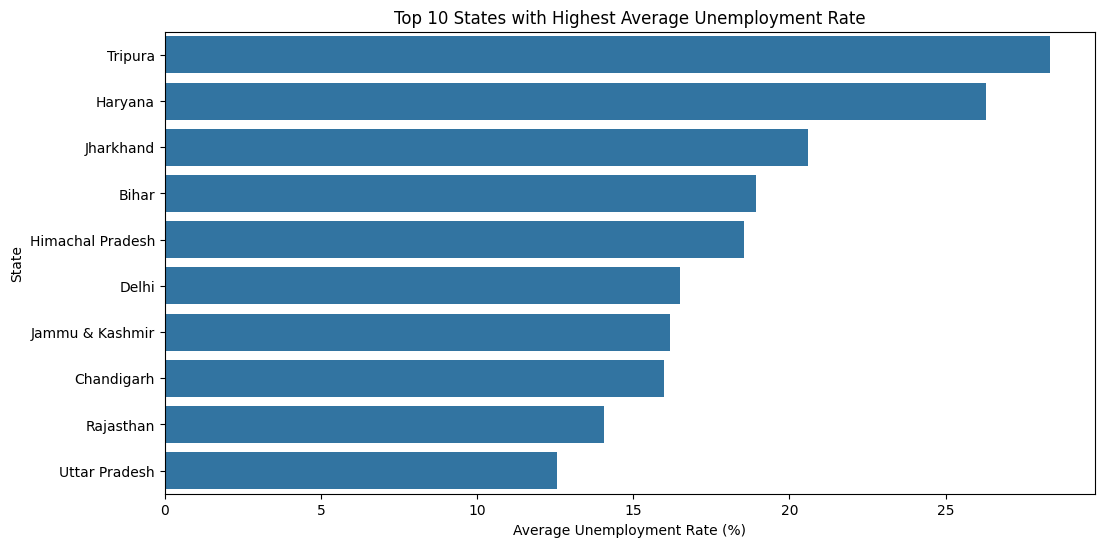

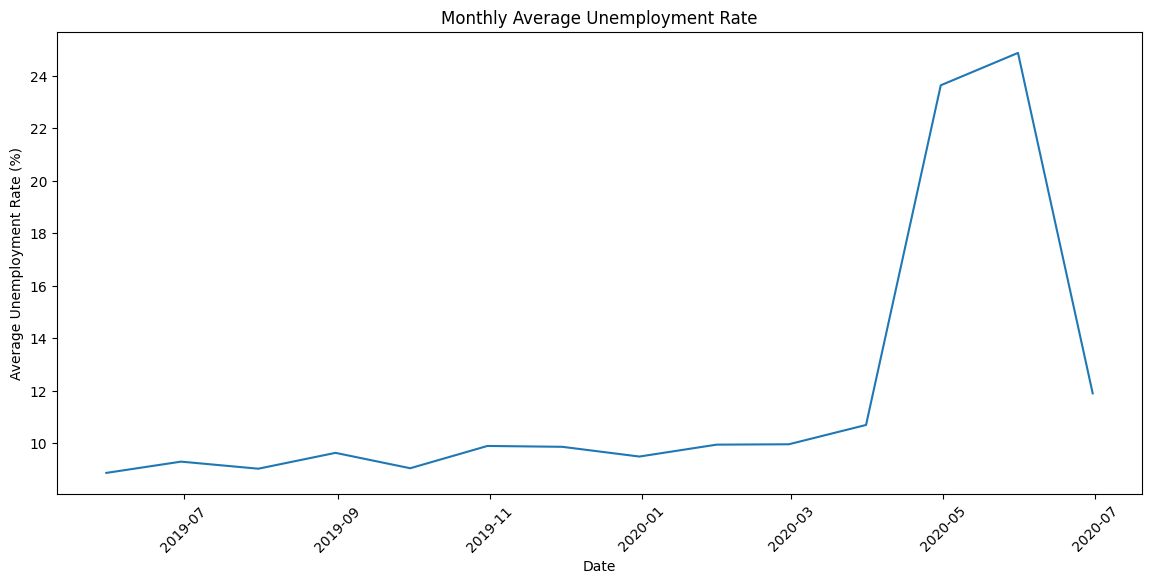

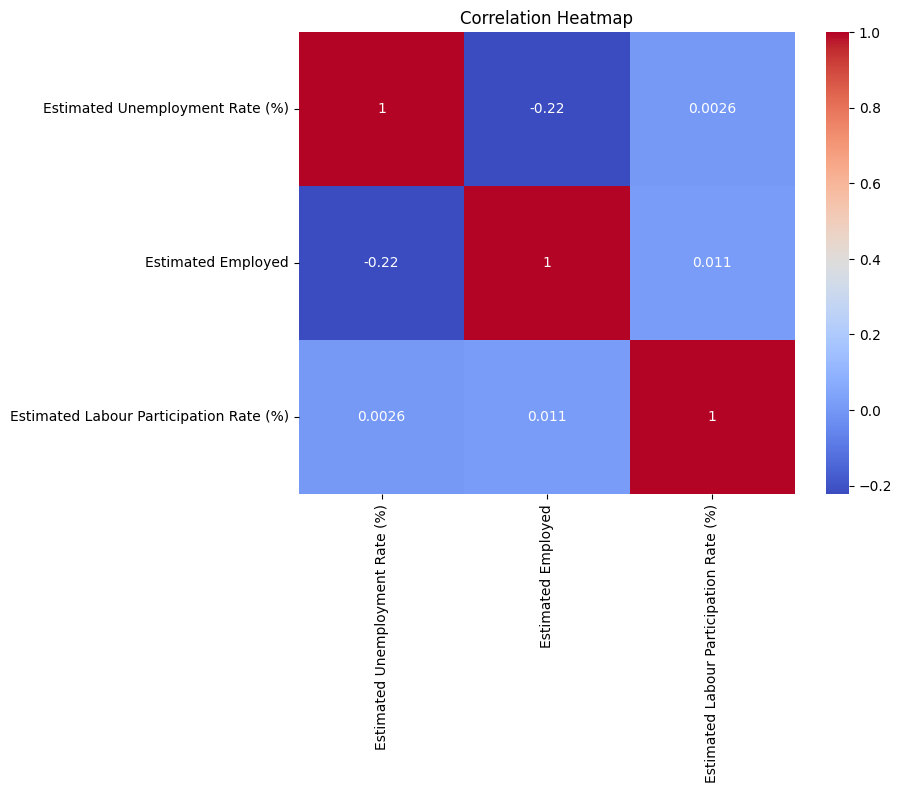

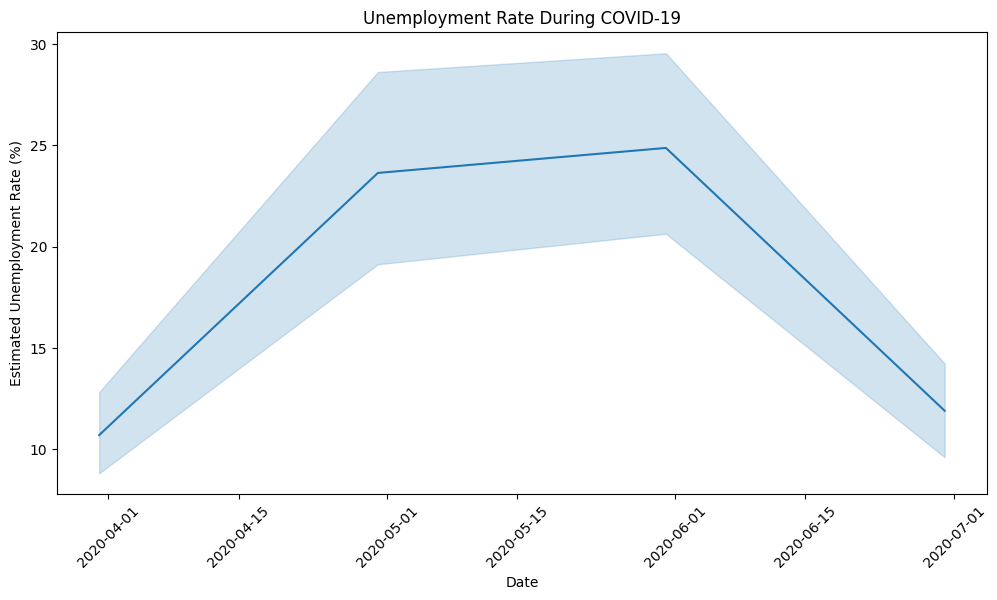

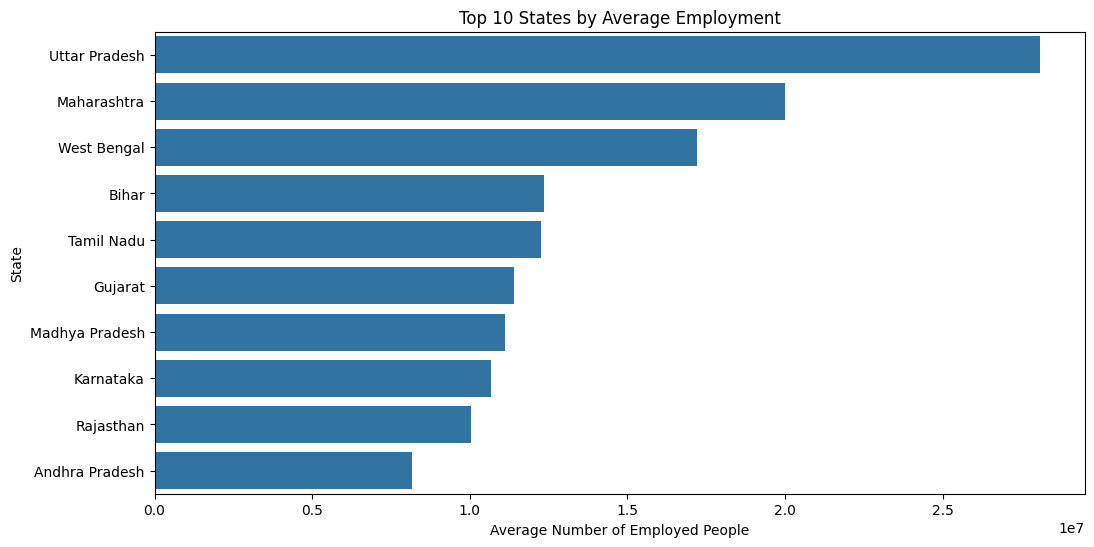

Cleaned dataset saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
# CodeAlpha Data Science Internship
# Task 2: Unemployment Analysis with Python

# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Load the Dataset
df = pd.read_csv("Unemployment in India.csv")

# Display the Dataset
#Let's view the first five rows of the dataset.
df.head()

# Data Understanding and Cleaning
df.shape
df.columns
df.info()
df.isnull().sum()
df.duplicated().sum()
df[' Date'] = pd.to_datetime(df[' Date'])
df.columns = df.columns.str.strip()
df.columns
df.info()
df.describe()

# Exploratory Data Analysis (EDA)

## Distribution of Unemployment Rate
plt.figure(figsize=(6,5))
sns.countplot(x='Area', data=df)
plt.title("Number of Records by Area")
plt.xlabel("Area")
plt.ylabel("Count")
plt.show()

## Number of Records by Area
plt.figure(figsize=(6,5))
sns.barplot(
    x='Area',
    y='Estimated Unemployment Rate (%)',
    data=df
)
plt.title("Average Unemployment Rate by Area")
plt.xlabel("Area")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()


## Average Unemployment Rate by Area
top_states = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_states.values,
    y=top_states.index
)
plt.title("Top 10 States with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")
plt.show()

## Top 10 States with Highest Average Unemployment
top_states = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_states.values,
    y=top_states.index
)
plt.title("Top 10 States with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")
plt.show()

## Monthly Unemployment Trend
monthly = (
    df.groupby('Date')['Estimated Unemployment Rate (%)']
      .mean()
      .reset_index()
)
plt.figure(figsize=(14,6))
plt.plot(
    monthly['Date'],
    monthly['Estimated Unemployment Rate (%)']
)
plt.title("Monthly Average Unemployment Rate")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

## Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()


## COVID-19 Impact Analysis
covid_data = df[df['Date'] >= '2020-03-01']
plt.figure(figsize=(12,6))
sns.lineplot(
    data=covid_data,
    x='Date',
    y='Estimated Unemployment Rate (%)'
)
plt.title("Unemployment Rate During COVID-19")
plt.xlabel("Date")
plt.ylabel("Estimated Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

## Top 10 States by Employment
top_employed = (
    df.groupby('Region')['Estimated Employed']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_employed.values,
    y=top_employed.index
)
plt.title("Top 10 States by Average Employment")
plt.xlabel("Average Number of Employed People")
plt.ylabel("State")
plt.show()

# Save the cleaned dataset
df.to_csv("Cleaned_Unemployment_Data.csv", index=False)
print("Cleaned dataset saved successfully!")

# Download CSV file
from google.colab import files
files.download("Cleaned_Unemployment_Data.csv")

